# Pandas Sales Case Study 

### Goal
Practice Pandas on the `sales_store.csv` dataset using realistic business questions.


In [1]:
import numpy as np 
import pandas as pd 

In [2]:
sales = pd.read_csv('Data Set/sales_store.csv')

#### **Data Processing**

In [21]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'], dayfirst=True)
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], dayfirst=True)

In [24]:
sales['Year'] = sales['Order Date'].dt.year
sales['Month'] = sales['Order Date'].dt.month
sales['Date'] = sales['Order Date'].dt.day

In [26]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Date
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11


#### **Question 1**

Which 10 products have the highest total sales? Display the result as a bar chart.

**Your solution:**



<Axes: xlabel='Product Name'>

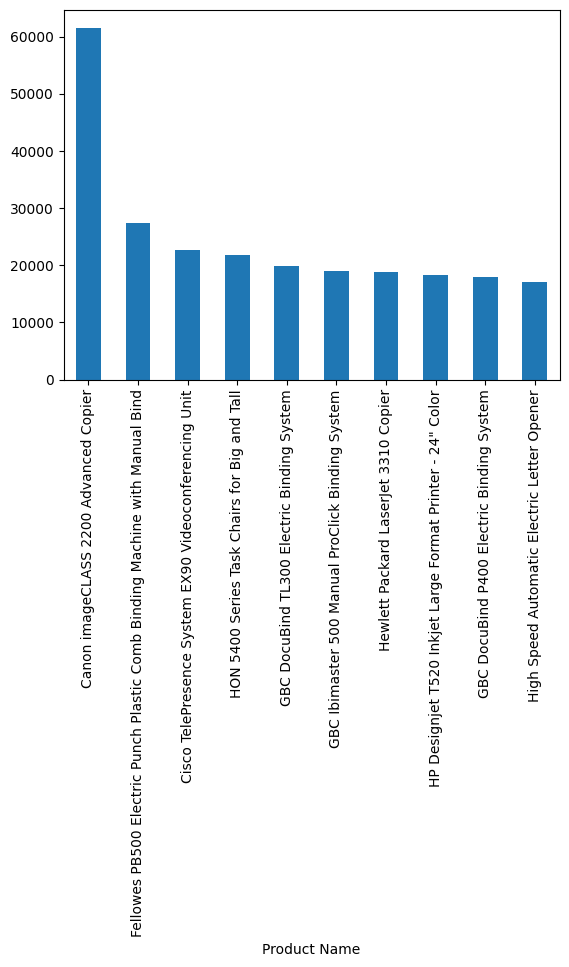

In [7]:
sales.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

#### **Question 2**

Which Region has the highest average sales per order? Return the average for every Region.

**Your solution:**



#### **Question 3**

What is the total sales generated by each Segment? Visualize the result using a pie chart.

**Your solution:**


<Axes: >

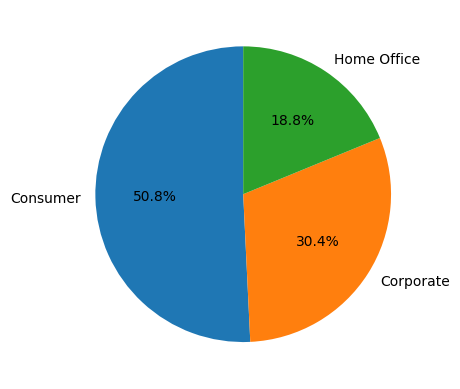

In [14]:
sales.groupby('Segment')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90, ylabel='')

#### **Question 4**

How do total sales change month by month? Create a line chart showing monthly sales.

**Your solution:**



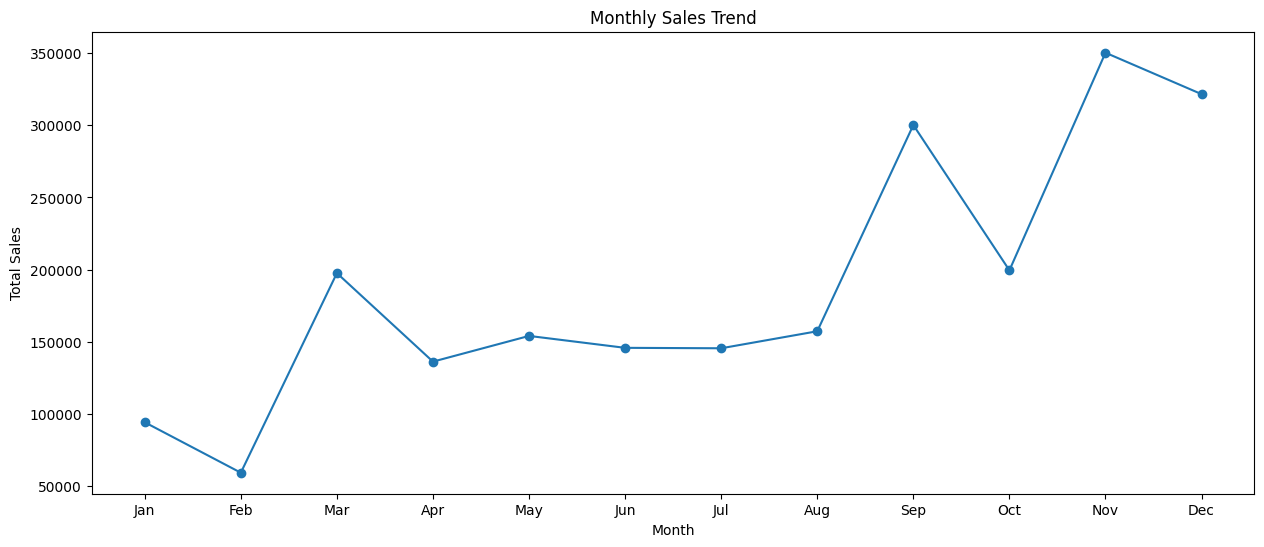

In [43]:
import calendar

# 1. Ensure Month Name is mapped
sales['Month Name'] = sales['Month'].apply(lambda x: calendar.month_abbr[int(x)])

# 2. Group by numeric Month AND Month Name so it sorts 1 through 12 automatically
monthly_sales = sales.groupby(['Month', 'Month Name'])['Sales'].sum().reset_index()

# 3. Plot specifying x='Month Name'
monthly_sales.plot(
    x='Month Name',
    y='Sales',
    kind='line',
    marker='o',
    figsize=(15, 6),
    xticks=range(12),
    legend=False,
    xlabel='Month',
    ylabel='Total Sales',
    title='Monthly Sales Trend'
);

#### **Question 5**

Which 10 states have the highest sales? Create a horizontal bar chart for the result.

**Your solution:**



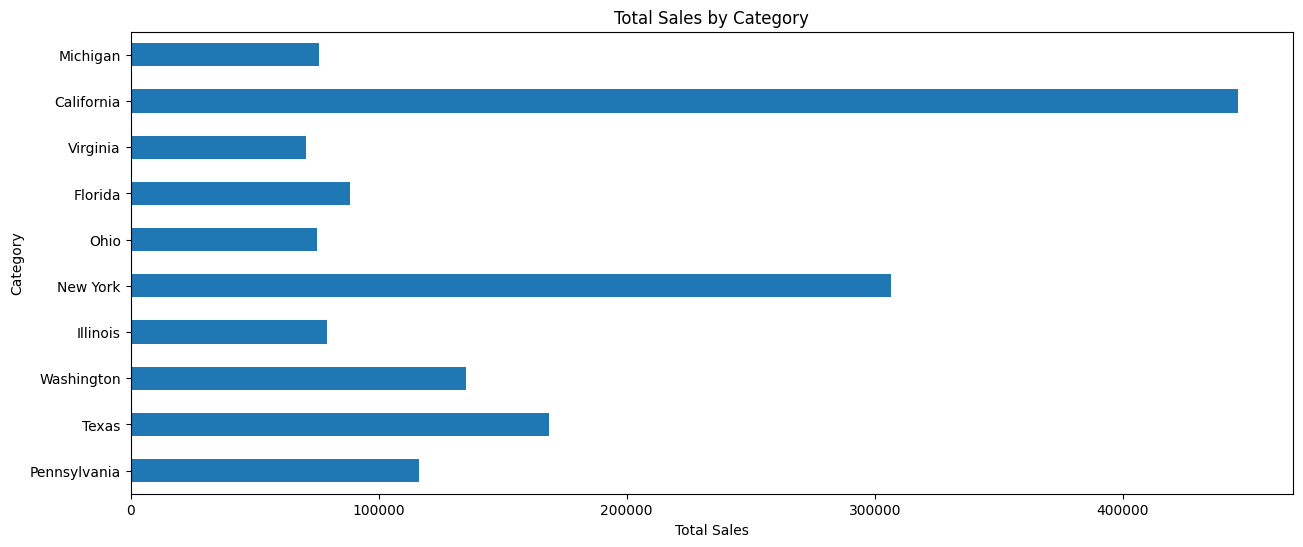

In [54]:
sales.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).sample(10).plot(
    kind='barh', 
    figsize=(15, 6),
    title='Total Sales by Category',
    xlabel='Total Sales',
    ylabel='Category'
);

#### **Question 6**

For each Category, what is the average sales per order? Which Category has the highest value?

**Your solution:**



In [93]:
order_sales = sales.groupby(['Category', 'Order ID'])['Sales'].sum().reset_index()

avg_sales_per_order = order_sales.groupby('Category')['Sales'].mean().round(2).sort_values(ascending=False)

avg_sales_per_order

Category
Technology         544.74
Furniture          421.92
Office Supplies    191.90
Name: Sales, dtype: float64

In [96]:
highest_category = avg_sales_per_order.idxmax()
highest_value = avg_sales_per_order.max()
print(f"Highest Category: {highest_category} (${highest_value:.2f})")

Highest Category: Technology ($544.74)


#### **Question 7**

Which Ship Mode has the longest average shipping time? Calculate the average number of days between Order Date and Ship Date for each Ship Mode.

**Your solution:**



In [56]:
sales['Shipping Days'] = (sales['Ship Date'] - sales['Order Date']).dt.days

In [59]:
sales.groupby('Ship Mode')['Shipping Days'].mean().round().astype(int)

Ship Mode
First Class       2
Same Day          0
Second Class      3
Standard Class    5
Name: Shipping Days, dtype: int64

#### **Question 8**

Which customers placed the most orders? Find the top 10 customers based on unique Order IDs and display their order counts.

**Your solution:**



In [63]:
sales.groupby('Customer Name')['Order ID'].count().sort_values(ascending=False).head(10)

Customer Name
William Brown          35
Paul Prost             34
Matt Abelman           34
John Lee               33
Seth Vernon            32
Chloris Kastensmidt    32
Jonathan Doherty       32
Arthur Prichep         31
Emily Phan             31
Zuschuss Carroll       31
Name: Order ID, dtype: int64

#### **Question 9**

How does the number of unique customers change across years? Calculate the yearly values and create a line chart.

**Your solution:**



In [100]:
yearly_customers = sales.groupby('Year')['Customer ID'].nunique().reset_index(name='Unique Customers')
print(yearly_customers)

   Year  Unique Customers
0  2015               589
1  2016               567
2  2017               635
3  2018               690


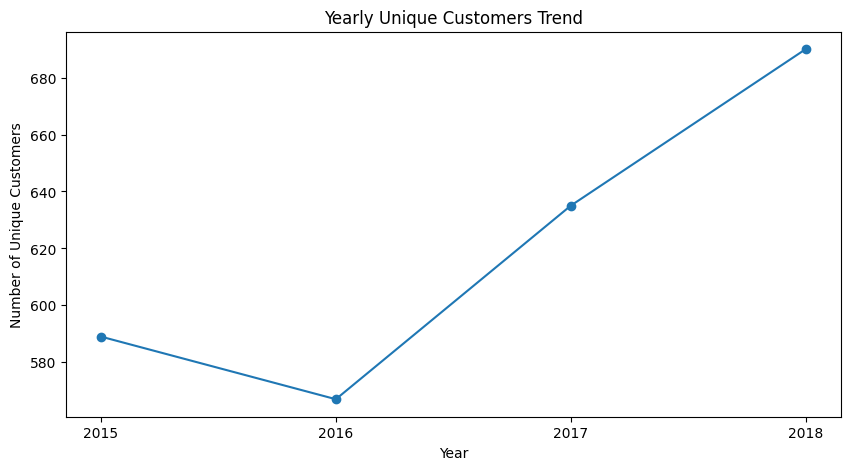

In [102]:
ax = yearly_customers.plot(
    x='Year',
    y='Unique Customers',
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=False,
    title='Yearly Unique Customers Trend',
    xlabel='Year',
    ylabel='Number of Unique Customers'
)

ax.set_xticks(yearly_customers['Year']);

#### **Question 10**
Which Sub-Categories generate the highest sales? Rank all Sub-Categories by total sales and visualize the top 10.

**Your solution:**



In [103]:
subcat_sales = (sales.groupby('Sub-Category')['Sales']
                .sum()
                .sort_values(ascending=False)
                .reset_index())

# Display full ranking table
print("--- Sub-Category Sales Ranking ---")
print(subcat_sales)

--- Sub-Category Sales Ranking ---
   Sub-Category        Sales
0        Phones  327782.4480
1        Chairs  322822.7310
2       Storage  219343.3920
3        Tables  202810.6280
4       Binders  200028.7850
5      Machines  189238.6310
6   Accessories  164186.7000
7       Copiers  146248.0940
8     Bookcases  113813.1987
9    Appliances  104618.4030
10  Furnishings   89212.0180
11        Paper   76828.3040
12     Supplies   46420.3080
13          Art   26705.4100
14    Envelopes   16128.0460
15       Labels   12347.7260
16    Fasteners    3001.9600


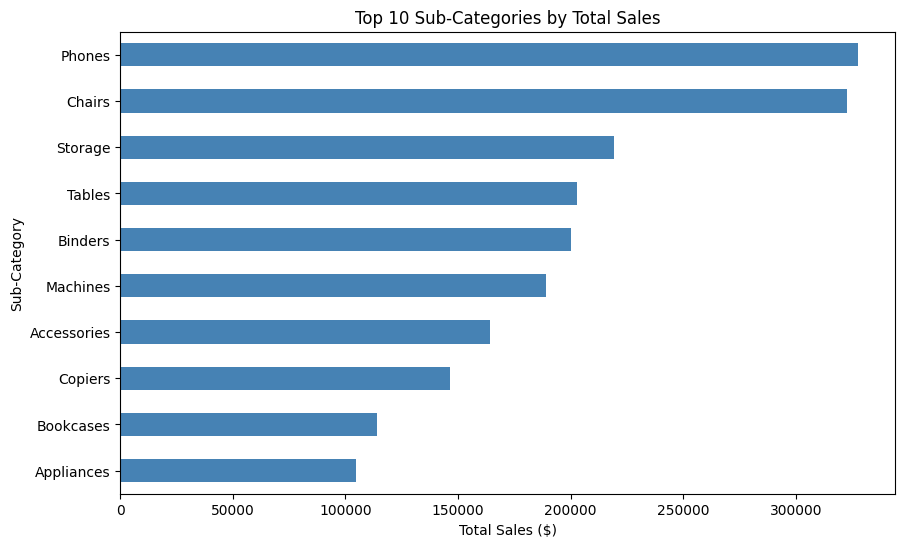

In [104]:
top10_subcats = subcat_sales.head(10).sort_values('Sales', ascending=True)

ax = top10_subcats.plot(
    x='Sub-Category',
    y='Sales',
    kind='barh',
    figsize=(10, 6),
    legend=False,
    color='steelblue',
    title='Top 10 Sub-Categories by Total Sales',
    xlabel='Total Sales ($)',
    ylabel='Sub-Category'
)

#### **Question 11**

Is there a relationship between the number of products in an order and the order's total sales? Calculate these values for each Order ID and create a scatter plot.

**Your solution:**



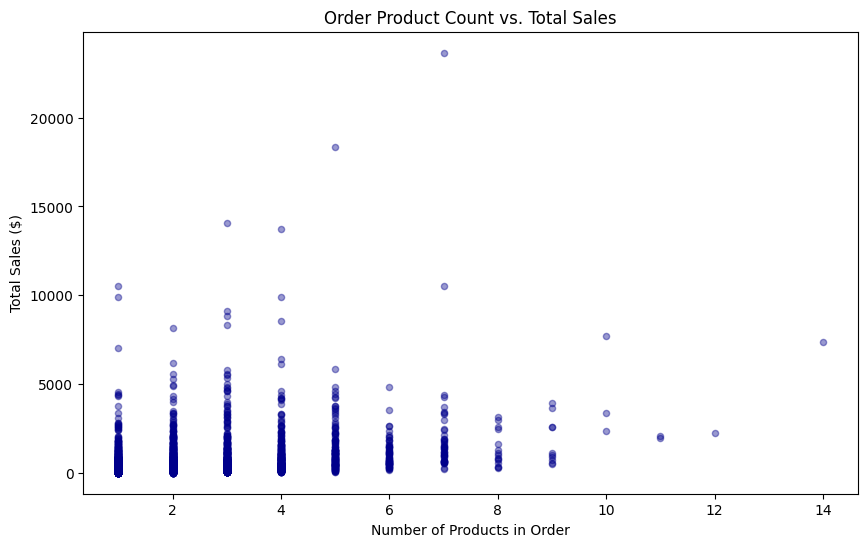

In [107]:
order_metrics = sales.groupby('Order ID').agg(
    Product_Count=('Product ID', 'count'),  
    Total_Sales=('Sales', 'sum')
).reset_index()


order_metrics.plot(
    x='Product_Count',
    y='Total_Sales',
    kind='scatter',
    figsize=(10, 6),
    alpha=0.4,
    color='darkblue',
    title='Order Product Count vs. Total Sales',
    xlabel='Number of Products in Order',
    ylabel='Total Sales ($)'
);

#### **Question 12**

Which Region has the highest sales for each Category? Create a table showing the best-performing Region for every Category.

**Your solution:**



In [74]:
cat_reg_sales = sales.groupby(['Category', 'Region'])['Sales'].sum().reset_index()

cat_reg_sales.sort_values(['Category', 'Sales'], ascending=[True, False]).groupby('Category').head(1)


,Category,Region,Sales
3,Furniture,West,245348.2455
7,Office Supplies,West,217466.5090
9,Technology,East,263116.5270


#### **Question 13**

Which cities have sales greater than the average city sales? Return the cities and their sales, sorted from highest to lowest.

**Your solution:**



In [80]:
city_sales = sales.groupby('City')['Sales'].sum()

In [81]:
city_sales[city_sales > city_sales.mean()].sort_values(ascending=False)

City
New York City    252462.547
Los Angeles      173420.181
Seattle          116106.322
San Francisco    109041.120
Philadelphia     108841.749
                    ...    
Troy               4507.091
Harrisonburg       4388.710
Toledo             4358.935
Oceanside          4350.738
Raleigh            4312.692
Name: Sales, Length: 91, dtype: float64

#### **Question 14**

Find customers who have purchased from at least 3 different Categories. Return the customers and the number of distinct Categories they purchased from.

**Your solution:**



In [99]:
(sales.groupby(['Customer ID', 'Customer Name'])['Category'].nunique().loc[lambda x: x >= 3].reset_index(name='Distinct_Category_Count') .sort_values('Distinct_Category_Count', ascending=False))

,Customer ID,Customer Name,Distinct_Category_Count
612,ZD-21925,Zuschuss Donatelli,3
0,AA-10315,Alex Avila,3
1,AA-10375,Allen Armold,3
2,AA-10480,Andrew Allen,3
3,AA-10645,Anna Andreadi,3
...,...,...,...
9,AB-10255,Alejandro Ballentine,3
8,AB-10165,Alan Barnes,3
7,AB-10150,Aimee Bixby,3
6,AB-10105,Adrian Barton,3


#### **Question 15**

For each year, find the month with the highest sales. Return one row per year containing the best month and its sales.

**Your solution:**



In [88]:
sales.groupby(['Year', 'Month'])['Sales'].sum().reset_index().sort_values('Sales', ascending=False).groupby('Year').first().reset_index()

,Year,Month,Sales
0,2015,9,81623.5268
1,2016,11,75249.3995
2,2017,12,95739.1210
3,2018,11,117938.1550


#### **Question 16**
Find the top 5 products in each Region based on total sales. Return a ranked result within every Region.

**Your solution:**



In [98]:
(sales.groupby(['Region', 'Product Name'])['Sales'].sum().reset_index().sort_values(['Region', 'Sales'], ascending=[True, False]).groupby('Region').head(5) .assign(Rank=lambda df: df.groupby('Region').cumcount() + 1).reset_index(drop=True))

,Region,Product Name,Sales,Rank
0,Central,Canon imageCLASS 2200 Advanced Copier,17499.950,1
1,Central,Lexmark MX611dhe Monochrome Laser Printer,14279.916,2
2,Central,Ibico EPK-21 Electric Binding System,11339.940,3
3,Central,GBC Ibimaster 500 Manual ProClick Binding System,10653.720,4
4,Central,GBC DocuBind P400 Electric Binding System,8710.336,5
5,East,Canon imageCLASS 2200 Advanced Copier,30099.914,1
6,East,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,2
7,East,"Riverside Palais Royal Lawyers Bookcase, Royal...",11717.034,3
8,East,GBC DocuBind TL300 Electric Binding System,8790.502,4
9,East,Hewlett Packard LaserJet 3310 Copier,8639.856,5


#### **Question 17**

Calculate each customer's first order date and last order date. Find the 10 customers with the longest time between their first and last orders.

**Your solution:**



In [89]:
# 1. Calculate first order date, last order date, and total order count per customer
customer_lifespan = sales.groupby(['Customer ID', 'Customer Name'])['Order Date'].agg(
    First_Order=('min'),
    Last_Order=('max')
).reset_index()
customer_lifespan

,Customer ID,Customer Name,First_Order,Last_Order
0,AA-10315,Alex Avila,2015-03-31,2018-06-29
1,AA-10375,Allen Armold,2015-04-21,2018-12-11
2,AA-10480,Andrew Allen,2015-05-04,2018-04-15
3,AA-10645,Anna Andreadi,2015-06-22,2018-11-05
4,AB-10015,Aaron Bergman,2015-02-18,2017-11-10
...,...,...,...,...
788,XP-21865,Xylona Preis,2015-01-20,2018-11-17
789,YC-21895,Yoseph Carroll,2015-11-17,2018-12-26
790,YS-21880,Yana Sorensen,2016-01-12,2018-12-21
791,ZC-21910,Zuschuss Carroll,2015-10-13,2018-11-06


In [91]:
# 2. Calculate the lifespan in days
customer_lifespan['Lifespan_Days'] = (customer_lifespan['Last_Order'] - customer_lifespan['First_Order']).dt.days
customer_lifespan

,Customer ID,Customer Name,First_Order,Last_Order,Lifespan_Days
0,AA-10315,Alex Avila,2015-03-31,2018-06-29,1186
1,AA-10375,Allen Armold,2015-04-21,2018-12-11,1330
2,AA-10480,Andrew Allen,2015-05-04,2018-04-15,1077
3,AA-10645,Anna Andreadi,2015-06-22,2018-11-05,1232
4,AB-10015,Aaron Bergman,2015-02-18,2017-11-10,996
...,...,...,...,...,...
788,XP-21865,Xylona Preis,2015-01-20,2018-11-17,1397
789,YC-21895,Yoseph Carroll,2015-11-17,2018-12-26,1135
790,YS-21880,Yana Sorensen,2016-01-12,2018-12-21,1074
791,ZC-21910,Zuschuss Carroll,2015-10-13,2018-11-06,1120


In [92]:
# 3. Get the top 10 customers with the longest lifespan
customer_lifespan.sort_values('Lifespan_Days', ascending=False).head(10)

,Customer ID,Customer Name,First_Order,Last_Order,Lifespan_Days
525,MM-17920,Michael Moore,2015-01-13,2018-12-23,1440
219,DL-13315,Delfina Latchford,2015-01-16,2018-12-08,1422
175,CS-12250,Chris Selesnick,2015-01-13,2018-12-04,1421
558,ND-18370,Natalie DeCherney,2015-01-13,2018-12-03,1420
293,GA-14725,Guy Armstrong,2015-02-11,2018-12-25,1413
544,MV-17485,Mark Van Huff,2015-01-20,2018-12-03,1413
497,ME-17320,Maria Etezadi,2015-01-06,2018-11-18,1412
106,BS-11590,Brendan Sweed,2015-01-14,2018-11-25,1411
485,MB-18085,Mick Brown,2015-01-05,2018-11-16,1411
545,MV-18190,Mike Vittorini,2015-01-30,2018-12-11,1411


#### **Question 18**

Which Sub-Categories are consistently strong across Regions? Calculate the total sales of every Sub-Category in every Region and identify Sub-Categories that rank in the top 5 in more than one Region.

**Your solution:**



In [71]:
ranks = sales.pivot_table(
    index='Sub-Category', 
    columns='Region', 
    values='Sales', 
    aggfunc='sum'
).rank(ascending=False, method='min')

In [72]:
top_5_region_counts = (ranks <= 5).sum(axis=1)
top_5_region_counts[top_5_region_counts > 1]

Sub-Category
Binders     2
Chairs      4
Machines    2
Phones      4
Storage     3
Tables      3
dtype: int64

#### **Question 19**

For every Category, calculate its percentage contribution to total company sales in each Region. Create a visualization that makes it easy to compare the Category mix across Regions.

**Your solution:**



In [65]:
region_cat_sales = sales.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

In [66]:
# A. Category Mix per Region (% of each Region's total sales)
category_mix = region_cat_sales.div(region_cat_sales.sum(axis=1), axis=0) * 100
print("--- Category Mix per Region (%) ---")
print(category_mix.round(2))

--- Category Mix per Region (%) ---
Category  Furniture  Office Supplies  Technology
Region                                          
Central       32.54            33.21       34.25
East          30.84            29.86       39.30
South         29.95            31.97       38.08
West          34.55            30.62       34.83


In [67]:
# B. Contribution to Overall Company Sales (% of grand total sales)
total_company_sales = sales['Sales'].sum()
overall_contribution = (region_cat_sales / total_company_sales) * 100
print("\n--- Contribution to Grand Total Sales (%) ---")
print(overall_contribution.round(2))


--- Contribution to Grand Total Sales (%) ---
Category  Furniture  Office Supplies  Technology
Region                                          
Central        7.09             7.23        7.46
East           9.13             8.84       11.63
South          5.15             5.50        6.55
West          10.85             9.62       10.94


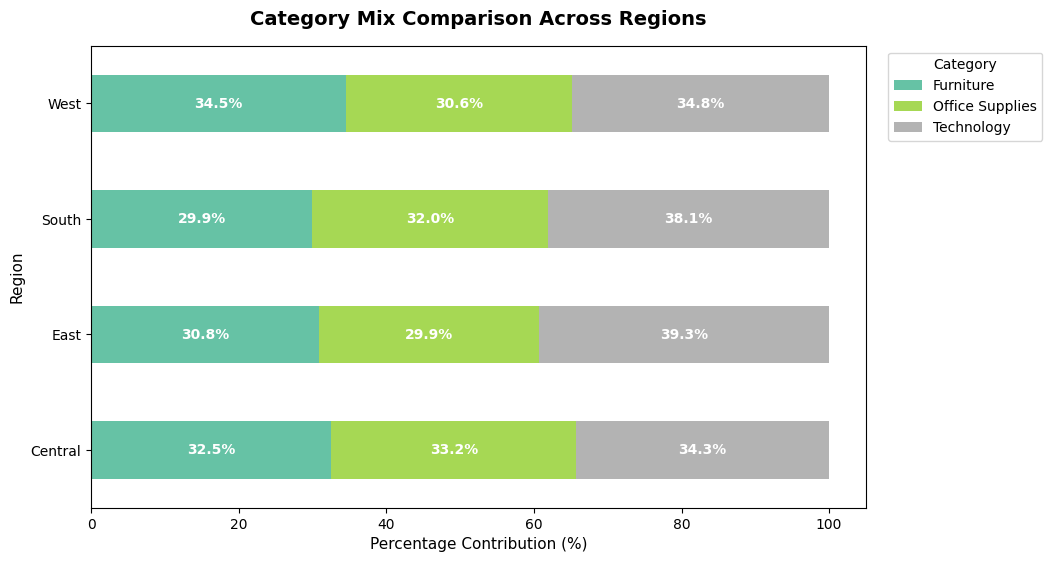

In [68]:
ax = category_mix.plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 6),
    colormap='Set2'
)

# Customization
ax.set_title('Category Mix Comparison Across Regions', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Percentage Contribution (%)', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add percentage annotations on bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if width > 5:  # Only annotate segments wide enough to fit text
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{width:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold')